# Part 4 — Prediction Modeling & Evaluation

**Owner**: A Dang dep zai

**Inputs**:
- `climate_anomaly_features.parquet` (Khiem)
- `flunet_clean.parquet` (Phong)
- `mobility_features.parquet` (Hieu)
- `graph_metrics.parquet` (Khiem)
- `mobility_edges.parquet` (Hieu) — airline graph edges for the GNN

**Models**: Ridge Regression · Gradient Boosting · A3T-GCN spatio-temporal GNN — the best-by-validation-RMSE model is deployed

**Outputs**: model results, per-country predictions, risk ranking, outbreak detection metrics

In [1]:
!pip install scikit-learn xgboost pyarrow matplotlib seaborn joblib -q
# A3T-GCN (Part 4b): PyTorch is preinstalled on Kaggle; PyG wheels must match torch+CUDA.
!pip install torch-geometric torch-geometric-temporal -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import hashlib, math, os, joblib
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
import warnings; warnings.filterwarnings('ignore')

# ═══ ĐỔI ĐƯỜNG DẪN Ở ĐÂY ═══
CLIMATE_IN  = '/kaggle/input/notebooks/khimnguynth/notebook-2-minhash-lsh/climate_anomaly_features.parquet'
FLUNET_IN   = '/kaggle/input/notebooks/phongngtun/merge-data/flunet_clean.parquet'
MOBILITY_IN = '/kaggle/input/notebooks/b22dccn320trnminhhiu/fork-of-notebook-3-pagerank/mobility_features.parquet'
GRAPH_IN    = '/kaggle/input/notebooks/b22dccn320trnminhhiu/fork-of-notebook-3-pagerank/graph_metrics.parquet'
RISK_IN     = '/kaggle/input/notebooks/b22dccn320trnminhhiu/fork-of-notebook-3-pagerank/risk_scores_timeseries.parquet'
EDGES_IN    = '/kaggle/input/notebooks/b22dccn320trnminhhiu/fork-of-notebook-3-pagerank/mobility_edges.parquet'
OUTPUT_DIR  = '/kaggle/working/'
# ══════════════════════════════

climate  = pd.read_parquet(CLIMATE_IN)
flunet   = pd.read_parquet(FLUNET_IN)
mobility = pd.read_parquet(MOBILITY_IN)
graph    = pd.read_parquet(GRAPH_IN)
edges    = pd.read_parquet(EDGES_IN)

# Load risk scores từ NB3
try:
    risk_ts = pd.read_parquet(RISK_IN)
    risk_ts['year'] = pd.to_numeric(risk_ts['year'], errors='coerce')
    risk_ts['week'] = pd.to_numeric(risk_ts['week'], errors='coerce')
    risk_ts['country_iso3'] = risk_ts['country_iso3'].astype(str).str.strip()
    HAS_RISK = True
    print(f'risk_ts:  {risk_ts.shape}')
except Exception as e:
    print(f'⚠️  risk_scores not found ({e}) — skipping risk features')
    risk_ts = pd.DataFrame()
    HAS_RISK = False

for df_ in [climate, flunet, mobility]:
    df_['year'] = pd.to_numeric(df_['year'], errors='coerce')
    df_['week'] = pd.to_numeric(df_['week'], errors='coerce')
    df_['country_iso3'] = df_['country_iso3'].astype(str).str.strip()

print(f'climate:  {climate.shape}')
print(f'flunet:   {flunet.shape}')
print(f'mobility: {mobility.shape}')
print(f'graph:    {graph.shape}')
print(f'edges:    {edges.shape}  cols={list(edges.columns)}')


risk_ts:  (279056, 6)
climate:  (202740, 35)
flunet:   (135870, 6)
mobility: (222984, 7)
graph:    (214, 10)
edges:    (2125, 3)  cols=['a', 'b', 'route_count']


## 4.2 Build Master Feature Table

In [3]:
flu = flunet[['country_iso3','year','week','flu_cases_total']].copy()
flu['flu_cases_total'] = pd.to_numeric(flu['flu_cases_total'], errors='coerce').fillna(0)
flu = flu.sort_values(['country_iso3','year','week'])
flu['flu_target_t2'] = flu.groupby('country_iso3')['flu_cases_total'].shift(-2)

anomaly_cols = [c for c in climate.columns if '_anomaly' in c and 'lag' not in c]
lag_cols     = [c for c in climate.columns if '_lag' in c]
graph_cols   = [c for c in ['pagerank_score','tspr_score','betweenness','degree_centrality','route_strength'] if c in graph.columns]

# Merge tất cả nguồn dữ liệu
mob_cols = ['country_iso3','year','week','mob_weighted_neighbor_flu']
# Thêm risk features từ mobility nếu có
for rc in ['risk_score', 'neighbor_flu_weighted']:
    if rc in mobility.columns and rc not in mob_cols:
        mob_cols.append(rc)

df_master = (
    flu
    .merge(climate, on=['country_iso3','year','week'], how='inner')
    .merge(mobility[[c for c in mob_cols if c in mobility.columns]],
           on=['country_iso3','year','week'], how='left')
    .merge(graph[['country_iso3']+graph_cols], on='country_iso3', how='left')
)

# Nếu risk_score chưa có trong mobility, merge từ risk_ts
if HAS_RISK and 'risk_score' not in df_master.columns:
    risk_merge_cols = ['country_iso3','year','week']
    for rc in ['risk_score', 'neighbor_flu_weighted']:
        if rc in risk_ts.columns:
            risk_merge_cols.append(rc)
    df_master = df_master.merge(risk_ts[risk_merge_cols],
                                 on=['country_iso3','year','week'], how='left')
    print(f'  → risk features merged from risk_ts')

df_master = df_master.dropna(subset=['flu_target_t2'])

# Feature lists
risk_feat_cols = [c for c in ['risk_score', 'neighbor_flu_weighted'] if c in df_master.columns]

FEAT_BASE = [c for c in anomaly_cols + lag_cols if c in df_master.columns]
FEAT_ENH  = FEAT_BASE + [c for c in
    ['mob_weighted_neighbor_flu', 'flu_cases_total'] + graph_cols + risk_feat_cols
    if c in df_master.columns
]
TARGET = 'flu_target_t2'

print(f'Master table: {df_master.shape}')
print(f'Countries: {df_master["country_iso3"].nunique()}')
print(f'Years: {sorted(df_master["year"].dropna().unique().astype(int))}')
print(f'Baseline features ({len(FEAT_BASE)}): {FEAT_BASE}')
print(f'Enhanced features ({len(FEAT_ENH)}): {FEAT_ENH}')
print(f'\nTarget (flu_cases t+2) distribution:')
print(df_master[TARGET].describe().round(2).to_string())


Master table: (89980, 45)
Countries: 119
Years: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Baseline features (19): ['temperature_c_anomaly', 'relative_humidity_anomaly', 'precipitation_mm_anomaly', 'temperature_c_anomaly_lag1', 'temperature_c_anomaly_lag2', 'temperature_c_anomaly_lag3', 'temperature_c_anomaly_lag4', 'relative_humidity_anomaly_lag1', 'relative_humidity_anomaly_lag2', 'relative_humidity_anomaly_lag3', 'relative_humidity_anomaly_lag4', 'precipitation_mm_anomaly_lag1', 'precipitation_mm_anomaly_lag2', 'precipitation_mm_anomaly_lag3', 'precipitation_mm_anomaly_lag4', 'climate_stress_index_lag1', 'climate_stress_index_lag2'

In [4]:
# Unified temporal split — identical boundaries for EVERY model (incl. the GNN),
# so validation RMSE is comparable for model selection.
#   train < 2018   |   val 2018-2019   |   test >= 2020   
def prepare_train_val_test(df, feats, target):
    sub = df[feats + [target, 'country_iso3', 'year', 'week']].dropna().copy()
    sub = sub.sort_values(['year', 'week', 'country_iso3']).reset_index(drop=True)

    train = sub[sub['year'] < 2018].copy()
    val   = sub[(sub['year'] >= 2018) & (sub['year'] <= 2019)].copy()
    test  = sub[sub['year'] >= 2020].copy()

    sc = StandardScaler().fit(train[feats].values)          # fit on TRAIN years only
    Xtr, Xva, Xte = (sc.transform(d[feats].values) for d in (train, val, test))
    return (Xtr, train[target].values, Xva, val[target].values,
            Xte, test[target].values, train, val, test, sc)

(Xtr_b, ytr_b, Xva_b, yva_b, Xte_b, yte_b, tr_b, va_b, te_b, sc_b) = \
    prepare_train_val_test(df_master, FEAT_BASE, TARGET)
(Xtr_e, ytr_e, Xva_e, yva_e, Xte_e, yte_e, tr_e, va_e, te_e, sc_e) = \
    prepare_train_val_test(df_master, FEAT_ENH, TARGET)

print('Split (train<2018 | val 2018-2019 | test>=2020):')
print(f'  baseline -> train {len(ytr_b):,} | val {len(yva_b):,} | test {len(yte_b):,}')
print(f'  enhanced -> train {len(ytr_e):,} | val {len(yva_e):,} | test {len(yte_e):,}')


Split (train<2018 | val 2018-2019 | test>=2020):
  baseline -> train 48,068 | val 9,696 | test 31,827
  enhanced -> train 46,575 | val 9,182 | test 30,043


## 4.3 Model Training & Evaluation

In [5]:
trained_models = {}

# Thử import XGBoost — nếu có thì dùng, không thì fallback sklearn GBM
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
    print('XGBoost available ✓')
except ImportError:
    HAS_XGB = False
    print('XGBoost not available — using sklearn GBM')

def build_candidates(algo):
    if algo == 'ridge':
        return [Ridge(alpha=a) for a in [0.1, 1.0, 5.0, 10.0]]
    if HAS_XGB:
        return [
            XGBRegressor(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                reg_alpha=0.1, reg_lambda=1.0,
                random_state=42, verbosity=0
            ),
            XGBRegressor(
                n_estimators=400, max_depth=5, learning_rate=0.03,
                subsample=0.85, colsample_bytree=0.7,
                reg_alpha=0.5, reg_lambda=2.0,
                random_state=42, verbosity=0
            ),
            XGBRegressor(
                n_estimators=300, max_depth=3, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9,
                reg_alpha=0.01, reg_lambda=0.5,
                random_state=42, verbosity=0
            ),
        ]
    return [
        GradientBoostingRegressor(
            n_estimators=150, max_depth=3, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42
        ),
        GradientBoostingRegressor(
            n_estimators=250, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=5, random_state=42
        ),
        GradientBoostingRegressor(
            n_estimators=300, max_depth=3, learning_rate=0.03,
            subsample=0.9, min_samples_leaf=3, random_state=42
        ),
    ]

def train_eval(Xtr, ytr, Xva, yva, Xte, yte, algo, label):
    # Model selection on validation split
    candidates = build_candidates(algo)
    best_model, best_val_rmse = None, np.inf
    for cand in candidates:
        cand.fit(Xtr, ytr)
        val_pred = np.maximum(cand.predict(Xva), 0)
        val_rmse = root_mean_squared_error(yva, val_pred)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model = cand

    # Refit best config on train+val, evaluate once on test
    X_fit = np.vstack([Xtr, Xva])
    y_fit = np.concatenate([ytr, yva])
    best_model.fit(X_fit, y_fit)
    pred = np.maximum(best_model.predict(Xte), 0)

    mae = mean_absolute_error(yte, pred)
    rmse = root_mean_squared_error(yte, pred)
    r2 = r2_score(yte, pred)

    # Outbreak detection (binary: flu > median threshold on fit set)
    thresh = float(np.median(y_fit[y_fit > 0])) if (y_fit > 0).any() else 1.0
    y_bin_true = (yte > thresh).astype(int)
    y_bin_pred = (pred > thresh).astype(int)
    prec = precision_score(y_bin_true, y_bin_pred, zero_division=0)
    rec = recall_score(y_bin_true, y_bin_pred, zero_division=0)
    f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)

    key = f'{algo}_{label}'
    trained_models[key] = {
        'model': best_model, 'pred': pred, 'actual': yte,
        'y_bin_true': y_bin_true, 'y_bin_pred': y_bin_pred,
        'thresh': thresh, 'Xte': Xte, 'test_df': None
    }

    print(f'  [{key:30s}]  ValRMSE={best_val_rmse:8.1f}  MAE={mae:8.1f}  RMSE={rmse:8.1f}  R2={r2:6.4f}  '
          f'Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}')

    return {
        'model': key, 'algorithm': algo, 'features': label,
        'Val_RMSE': round(float(best_val_rmse), 3),
        'MAE': round(float(mae), 3), 'RMSE': round(float(rmse), 3), 'R2': round(float(r2), 4),
        'Precision': round(float(prec), 3), 'Recall': round(float(rec), 3), 'F1': round(float(f1), 3),
        'n_test': len(yte)
    }

print('=== MODEL TRAINING (train/val/test pipeline) ===' + '=' * 20)
print(f'  {"Model":30s}  {"ValRMSE":>9s}  {"MAE":>9s}  {"RMSE":>9s}  {"R2":>7s}  '
      f'{"Prec":>7s}  {"Rec":>7s}  {"F1":>7s}')
print('  ' + '-' * 105)

all_results = []
for algo in ['ridge', 'gbm']:
    all_results.append(train_eval(Xtr_b, ytr_b, Xva_b, yva_b, Xte_b, yte_b, algo, 'baseline'))
    all_results.append(train_eval(Xtr_e, ytr_e, Xva_e, yva_e, Xte_e, yte_e, algo, 'enhanced'))

results_df = pd.DataFrame(all_results)
# Store test_df reference for downstream charts
for k in trained_models:
    trained_models[k]['test_df'] = te_e if 'enhanced' in k else te_b


XGBoost available ✓
=== MODEL TRAINING (train/val/test pipeline) =======================
  Model                             ValRMSE        MAE       RMSE       R2     Prec      Rec       F1
  ---------------------------------------------------------------------------------------------------------
  [ridge_baseline                ]  ValRMSE=   808.5  MAE=   164.9  RMSE=  1208.2  R2=-0.0017  Prec=0.270  Rec=1.000  F1=0.426
  [ridge_enhanced                ]  ValRMSE=   301.6  MAE=    57.8  RMSE=   552.4  R2=0.8022  Prec=0.654  Rec=0.883  F1=0.751
  [gbm_baseline                  ]  ValRMSE=   804.7  MAE=   157.9  RMSE=  1198.9  R2=0.0136  Prec=0.283  Rec=0.910  F1=0.432
  [gbm_enhanced                  ]  ValRMSE=   324.1  MAE=    65.7  RMSE=   734.9  R2=0.6500  Prec=0.771  Rec=0.870  F1=0.817


## 4.3b A3T-GCN — Spatio-Temporal Graph Neural Network (inline)

Predicts flu **2 weeks ahead** per country with message-passing over the airline-mobility
graph + a GRU/temporal-attention over weeks. Trained on the **same master table, target and
split** as the tabular models, so its validation RMSE is directly comparable.

Absent country-weeks (~42% of the dense grid) are handled with an **observed-mask channel**
(literal-0 features + an indicator), the one fix that helped; the static graph is kept
(per-snapshot edge pruning was tested and *hurt*). The graph is tiny, so CPU is fine
(~30–45 min); a GPU is optional.

In [6]:
import torch
import torch.nn as nn
from torch_geometric_temporal.nn.recurrent import A3TGCN

# --- Graph from airline-mobility edges (undirected, log1p route weights) ---
nodes = sorted(df_master['country_iso3'].unique())
node_idx = {c: i for i, c in enumerate(nodes)}
N = len(nodes)
src, dst, w = [], [], []
for a, b, rc in edges[['a', 'b', 'route_count']].itertuples(index=False):
    if a in node_idx and b in node_idx and a != b:
        wi = math.log1p(float(rc))
        src += [node_idx[a], node_idx[b]]; dst += [node_idx[b], node_idx[a]]; w += [wi, wi]
edge_index  = torch.tensor([src, dst], dtype=torch.long)
edge_weight = torch.tensor(w, dtype=torch.float)
edge_weight = edge_weight / (edge_weight.max() + 1e-9)
print(f'Graph: {N} nodes | {edge_index.shape[1]} directed edges')

# --- Dense spatio-temporal tensors (T, N, F) with an observed-mask channel ---
df_master['season_sin'] = np.sin(2 * np.pi * df_master['week'] / 52.0)
df_master['season_cos'] = np.cos(2 * np.pi * df_master['week'] / 52.0)
time_varying = [c for c in (anomaly_cols + lag_cols +
                ['flu_cases_total', 'mob_weighted_neighbor_flu', 'risk_score'])
                if c in df_master.columns]
static_graph = [c for c in graph_cols if c in df_master.columns]
FEAT_GNN = time_varying + static_graph + ['season_sin', 'season_cos']
assert TARGET not in FEAT_GNN, 'leakage: target in features!'
N_FEAT = len(FEAT_GNN)
F = N_FEAT + 1                                      # + 1 observed-mask indicator channel

snaps = (df_master[['year', 'week']].drop_duplicates()
         .sort_values(['year', 'week']).reset_index(drop=True))
snaps['t'] = np.arange(len(snaps)); T = len(snaps)
df_master = df_master.merge(snaps, on=['year', 'week'], how='left')

sc_gnn = StandardScaler()
train_rows = (df_master['year'] < 2018).values
sc_gnn.fit(df_master.loc[train_rows, FEAT_GNN].astype(float).fillna(0).values)
feat_scaled = sc_gnn.transform(df_master[FEAT_GNN].astype(float).fillna(0).values).astype(np.float32)
row_t = df_master['t'].values.astype(int)
row_n = df_master['country_iso3'].map(node_idx).values.astype(int)
tgt   = pd.to_numeric(df_master[TARGET], errors='coerce').values.astype(np.float32)

X = np.zeros((T, N, F), np.float32); Y = np.zeros((T, N), np.float32); mask = np.zeros((T, N), bool)
X[row_t, row_n, :N_FEAT] = feat_scaled
Y[row_t, row_n]          = np.nan_to_num(tgt, nan=0.0)
mask[row_t, row_n]       = ~np.isnan(tgt)
X[:, :, :N_FEAT] *= mask[:, :, None]               # (#2) absent cells = literal 0, not the mean
X[:, :, N_FEAT]   = mask.astype(np.float32)        # (#1) observed-indicator channel
print(f'Tensors: X{X.shape}  Y{Y.shape}  | valid cells {mask.sum():,}/{T*N:,}')

# --- Windowing + the SAME split (train<2018 | val 2018-2019 | test>=2020) ---
L = 8
feats_list, masks_list, orig_t = [], [], []
for t in range(L - 1, T):
    feats_list.append(np.transpose(X[t - L + 1:t + 1], (1, 2, 0)).astype(np.float32))  # (N,F,L)
    masks_list.append(mask[t].copy()); orig_t.append(t)
feat_t   = torch.from_numpy(np.stack(feats_list))
targ_t   = torch.from_numpy(np.stack([Y[t] for t in orig_t]))
mask_t   = torch.from_numpy(np.stack(masks_list))
targ_log = torch.log1p(torch.clamp(targ_t, min=0))
snap_year = snaps['year'].values[np.array(orig_t)]
train_s = np.where(snap_year < 2018)[0]
val_s   = np.where((snap_year >= 2018) & (snap_year <= 2019))[0]
test_s  = np.where(snap_year >= 2020)[0]
print(f'GNN snapshots: {len(orig_t)} | train={len(train_s)} val={len(val_s)} test={len(test_s)}')


Graph: 119 nodes | 2542 directed edges
Tensors: X(1302, 119, 30)  Y(1302, 119)  | valid cells 89,980/154,938
GNN snapshots: 1295 | train=880 val=104 test=311


In [7]:
class FluA3TGCN(nn.Module):
    def __init__(self, in_channels, hidden=32, periods=8, dropout=0.3):
        super().__init__()
        self.tgnn = A3TGCN(in_channels=in_channels, out_channels=hidden, periods=periods)
        self.drop = nn.Dropout(dropout); self.head = nn.Linear(hidden, 1)
    def forward(self, x, ei, ew):
        h = self.drop(torch.relu(self.tgnn(x, ei, ew)))   # (N, hidden), log space
        return self.head(h).squeeze(-1)                   # (N,)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)
gnn = FluA3TGCN(F, hidden=32, periods=L, dropout=0.3).to(device)
ei, ew = edge_index.to(device), edge_weight.to(device)          # static graph
feat_d, tlog_d = feat_t.to(device), targ_log.to(device)
targ_d, mask_d = targ_t.to(device), mask_t.to(device)
opt = torch.optim.Adam(gnn.parameters(), lr=1e-2, weight_decay=1e-4)
huber = nn.HuberLoss(delta=1.0)
print(f'Device: {device} | A3T-GCN params: {sum(p.numel() for p in gnn.parameters()):,}')

def gnn_val_rmse(idxs):
    gnn.eval(); P, A = [], []
    with torch.no_grad():
        for s in idxs:
            pr = torch.clamp(torch.expm1(gnn(feat_d[s], ei, ew)), min=0); m = mask_d[s]
            P.append(pr[m]); A.append(targ_d[s][m])
    P, A = torch.cat(P), torch.cat(A)
    return torch.sqrt(((P - A) ** 2).mean()).item()

best_rmse, best_state, bad, PATIENCE = np.inf, None, 0, 30
rng = np.random.RandomState(42)
for epoch in range(200):
    gnn.train(); tot = 0.0
    for s in rng.permutation(train_s):
        m = mask_d[s]
        if m.sum() == 0: continue
        opt.zero_grad()
        loss = huber(gnn(feat_d[s], ei, ew)[m], tlog_d[s][m])
        loss.backward(); opt.step(); tot += loss.item()
    vr = gnn_val_rmse(val_s)
    if vr < best_rmse:
        best_rmse, bad = vr, 0
        best_state = {k: v.detach().cpu().clone() for k, v in gnn.state_dict().items()}
    else:
        bad += 1
    if epoch % 10 == 0 or bad == 0:
        print(f'epoch {epoch:3d} | huber={tot/max(len(train_s),1):.4f} | val_RMSE={vr:8.1f} | best={best_rmse:8.1f}')
    if bad >= PATIENCE:
        print(f'Early stop @ epoch {epoch} (best val_RMSE={best_rmse:.1f})'); break
gnn.load_state_dict(best_state)

# --- Test (2020+) predictions + metrics, SAME schema as the tabular leaderboard ---
gnn.eval(); rows = []
with torch.no_grad():
    for s in test_s:
        pr = torch.clamp(torch.expm1(gnn(feat_d[s], ei, ew)), min=0).cpu().numpy()
        m = masks_list[s]; t = orig_t[s]
        yr, wk = int(snaps.loc[t, 'year']), int(snaps.loc[t, 'week'])
        for n in np.where(m)[0]:
            rows.append((nodes[n], yr, wk, float(Y[t, n]), float(pr[n])))
gnn_pred_df = pd.DataFrame(rows, columns=['country_iso3', 'year', 'week', 'actual', 'pred'])
yte_g, pred_g = gnn_pred_df['actual'].values, gnn_pred_df['pred'].values

fit_vals = np.concatenate([Y[orig_t[s]][masks_list[s]] for s in np.concatenate([train_s, val_s])])
thresh_g = float(np.median(fit_vals[fit_vals > 0])) if (fit_vals > 0).any() else 1.0
ybt, ybp = (yte_g > thresh_g).astype(int), (pred_g > thresh_g).astype(int)
gnn_row = {
    'model': 'gnn_a3tgcn', 'algorithm': 'gnn', 'features': 'enhanced',
    'Val_RMSE': round(float(best_rmse), 3),
    'MAE':  round(float(mean_absolute_error(yte_g, pred_g)), 3),
    'RMSE': round(float(root_mean_squared_error(yte_g, pred_g)), 3),
    'R2':   round(float(r2_score(yte_g, pred_g)), 4),
    'Precision': round(float(precision_score(ybt, ybp, zero_division=0)), 3),
    'Recall':    round(float(recall_score(ybt, ybp, zero_division=0)), 3),
    'F1':        round(float(f1_score(ybt, ybp, zero_division=0)), 3),
    'n_test': int(len(yte_g)),
}
trained_models['gnn_a3tgcn'] = {
    'model': gnn, 'pred': pred_g, 'actual': yte_g,
    'y_bin_true': ybt, 'y_bin_pred': ybp, 'thresh': thresh_g,
    'Xte': None, 'test_df': None, 'pred_df': gnn_pred_df,
}
all_results = [r for r in all_results if r['model'] != 'gnn_a3tgcn'] + [gnn_row]
results_df = pd.DataFrame(all_results)
print('\nLeaderboard with GNN (sorted by validation RMSE):')
print(results_df[['model','Val_RMSE','MAE','RMSE','R2','F1']]
      .sort_values('Val_RMSE').to_string(index=False))


Device: cpu | A3T-GCN params: 9,257
epoch   0 | huber=0.7061 | val_RMSE=   793.7 | best=   793.7
epoch   2 | huber=0.6377 | val_RMSE=   768.1 | best=   768.1
epoch   3 | huber=0.6337 | val_RMSE=   750.6 | best=   750.6
epoch   7 | huber=0.6135 | val_RMSE=   699.6 | best=   699.6
epoch  10 | huber=0.6055 | val_RMSE=   778.1 | best=   699.6
epoch  20 | huber=0.5904 | val_RMSE=   713.8 | best=   699.6
epoch  21 | huber=0.5850 | val_RMSE=   695.4 | best=   695.4
epoch  30 | huber=0.5735 | val_RMSE=   766.8 | best=   695.4
epoch  34 | huber=0.5670 | val_RMSE=   677.1 | best=   677.1
epoch  36 | huber=0.5673 | val_RMSE=   636.8 | best=   636.8
epoch  39 | huber=0.5678 | val_RMSE=   561.4 | best=   561.4
epoch  40 | huber=0.5635 | val_RMSE=   681.7 | best=   561.4
epoch  50 | huber=0.5609 | val_RMSE=   790.8 | best=   561.4
epoch  60 | huber=0.5569 | val_RMSE=   615.1 | best=   561.4
Early stop @ epoch 69 (best val_RMSE=561.4)

Leaderboard with GNN (sorted by validation RMSE):
         model 

## 4.4 Results Overview — Comprehensive Plot

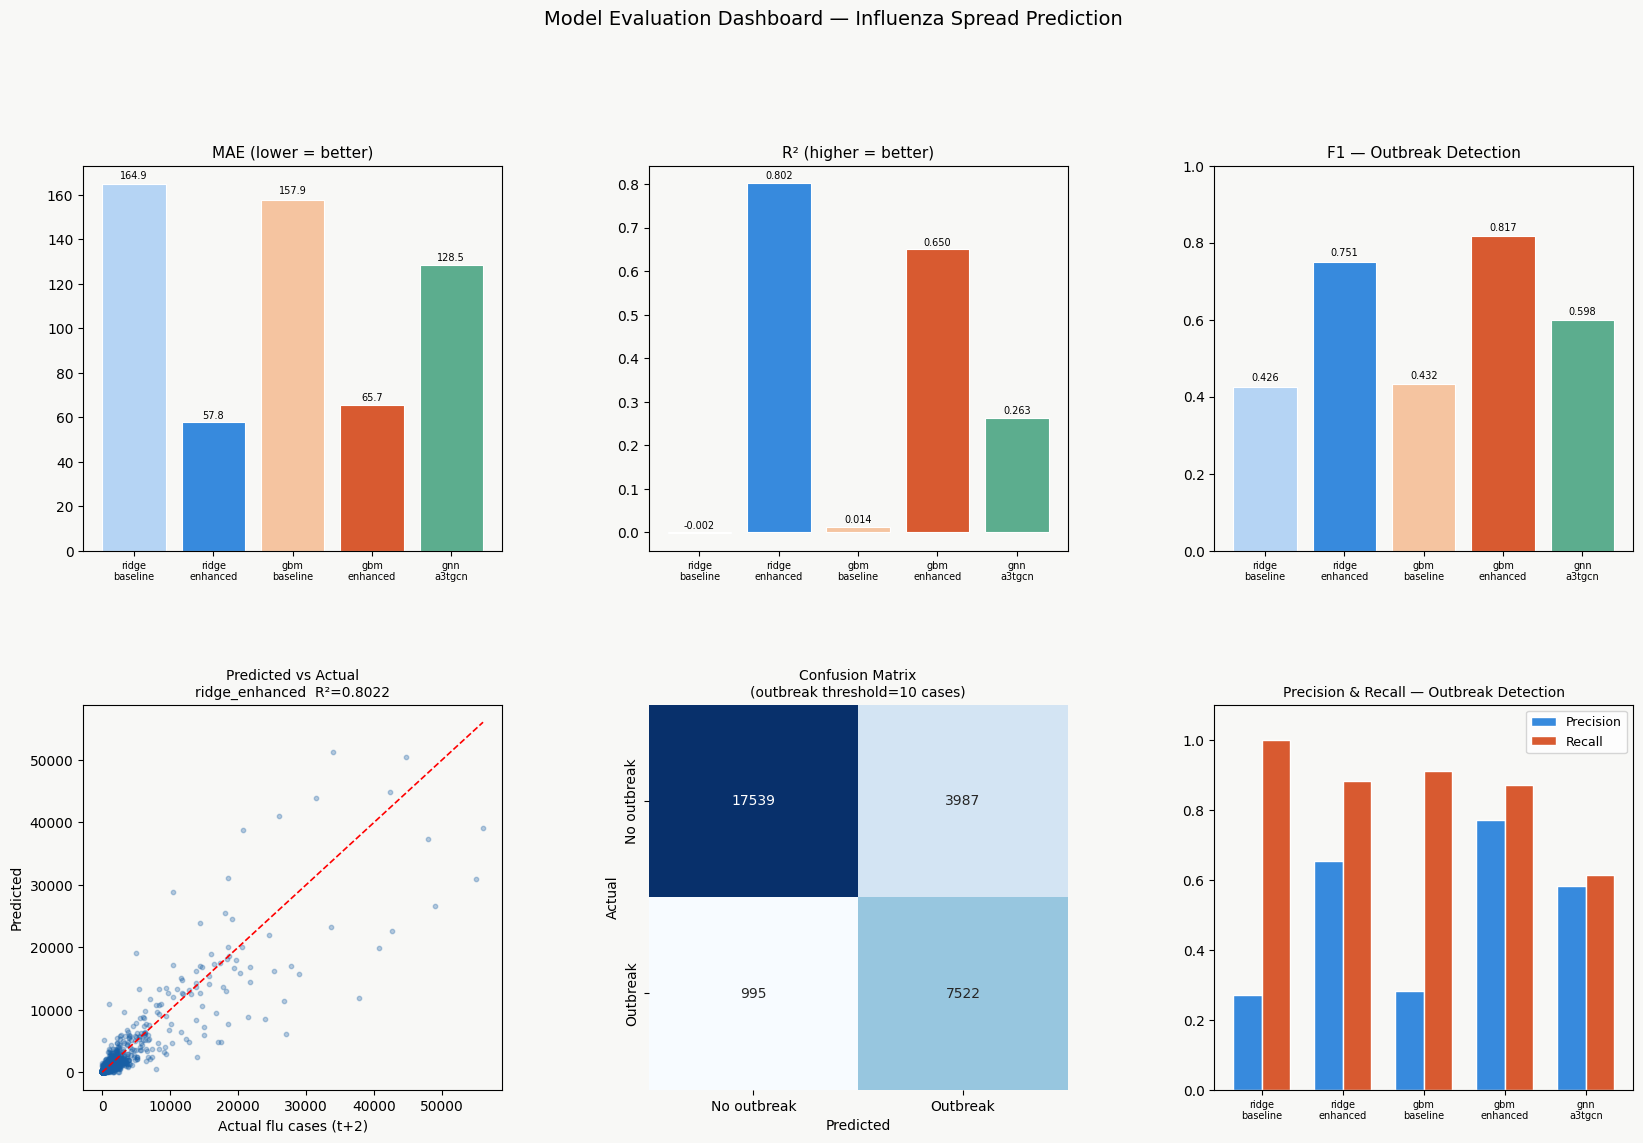

✓ Saved model_dashboard.png  (best model: ridge_enhanced)


In [8]:
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

color_map = {
    'ridge_baseline': '#B5D4F4', 'ridge_enhanced': '#378ADD',
    'gbm_baseline':   '#F5C4A0', 'gbm_enhanced':   '#D85A30',
    'gnn_a3tgcn':     '#5CAD8E',
}
colors = [color_map.get(m, '#888') for m in results_df['model']]
labels = results_df['model'].str.replace('_', '\n')

# ─ MAE
ax1 = fig.add_subplot(gs[0,0])
bars = ax1.bar(range(len(results_df)), results_df['MAE'], color=colors, edgecolor='white', linewidth=0.8)
ax1.set_xticks(range(len(results_df))); ax1.set_xticklabels(labels, fontsize=7)
ax1.set_title('MAE (lower = better)', fontsize=11)
for b, v in zip(bars, results_df['MAE']): ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01*b.get_height(), f'{v:.1f}', ha='center', va='bottom', fontsize=7)
ax1.set_facecolor('#f8f8f6')

# ─ R²
ax2 = fig.add_subplot(gs[0,1])
bars = ax2.bar(range(len(results_df)), results_df['R2'], color=colors, edgecolor='white', linewidth=0.8)
ax2.set_xticks(range(len(results_df))); ax2.set_xticklabels(labels, fontsize=7)
ax2.set_title('R² (higher = better)', fontsize=11)
for b, v in zip(bars, results_df['R2']): ax2.text(b.get_x()+b.get_width()/2, max(b.get_height()+0.005,0.005), f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax2.set_facecolor('#f8f8f6')

# ─ F1 (outbreak detection)
ax3 = fig.add_subplot(gs[0,2])
bars = ax3.bar(range(len(results_df)), results_df['F1'], color=colors, edgecolor='white', linewidth=0.8)
ax3.set_xticks(range(len(results_df))); ax3.set_xticklabels(labels, fontsize=7)
ax3.set_title('F1 — Outbreak Detection', fontsize=11)
ax3.set_ylim(0, 1)
for b, v in zip(bars, results_df['F1']): ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax3.set_facecolor('#f8f8f6')

# ─ Best model: Predicted vs Actual scatter
best_key = results_df.loc[results_df['R2'].idxmax(), 'model']
best = trained_models[best_key]
ax4 = fig.add_subplot(gs[1,0])
ax4.scatter(best['actual'], best['pred'], alpha=0.3, s=10, color='#185FA5')
mx = max(best['actual'].max(), best['pred'].max())
ax4.plot([0,mx],[0,mx], 'r--', linewidth=1.2)
ax4.set_xlabel('Actual flu cases (t+2)'); ax4.set_ylabel('Predicted')
r2_best = results_df.loc[results_df['model']==best_key,'R2'].values[0]
ax4.set_title(f'Predicted vs Actual\n{best_key}  R²={r2_best:.4f}', fontsize=10)
ax4.set_facecolor('#f8f8f6')

# ─ Confusion matrix (best model outbreak detection)
ax5 = fig.add_subplot(gs[1,1])
cm_vals = confusion_matrix(best['y_bin_true'], best['y_bin_pred'])
sns.heatmap(cm_vals, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['No outbreak','Outbreak'], yticklabels=['No outbreak','Outbreak'],
            cbar=False)
ax5.set_title(f'Confusion Matrix\n(outbreak threshold={best["thresh"]:.0f} cases)', fontsize=10)
ax5.set_xlabel('Predicted'); ax5.set_ylabel('Actual')

# ─ Precision / Recall comparison
ax6 = fig.add_subplot(gs[1,2])
x = np.arange(len(results_df))
w = 0.35
ax6.bar(x-w/2, results_df['Precision'], w, label='Precision', color='#378ADD', edgecolor='white')
ax6.bar(x+w/2, results_df['Recall'],    w, label='Recall',    color='#D85A30', edgecolor='white')
ax6.set_xticks(x); ax6.set_xticklabels(labels, fontsize=7)
ax6.set_title('Precision & Recall — Outbreak Detection', fontsize=10)
ax6.set_ylim(0, 1.1); ax6.legend(fontsize=9)
ax6.set_facecolor('#f8f8f6')

for ax in [ax1,ax2,ax3,ax4,ax5,ax6]: ax.figure.patch.set_facecolor('#f8f8f6')
fig.suptitle('Model Evaluation Dashboard — Influenza Spread Prediction', fontsize=14, y=1.01)
plt.savefig(OUTPUT_DIR+'model_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved model_dashboard.png  (best model: {best_key})')

## 4.5 Per-Country Prediction Time Series

Show actual vs predicted flu cases over time for selected countries.

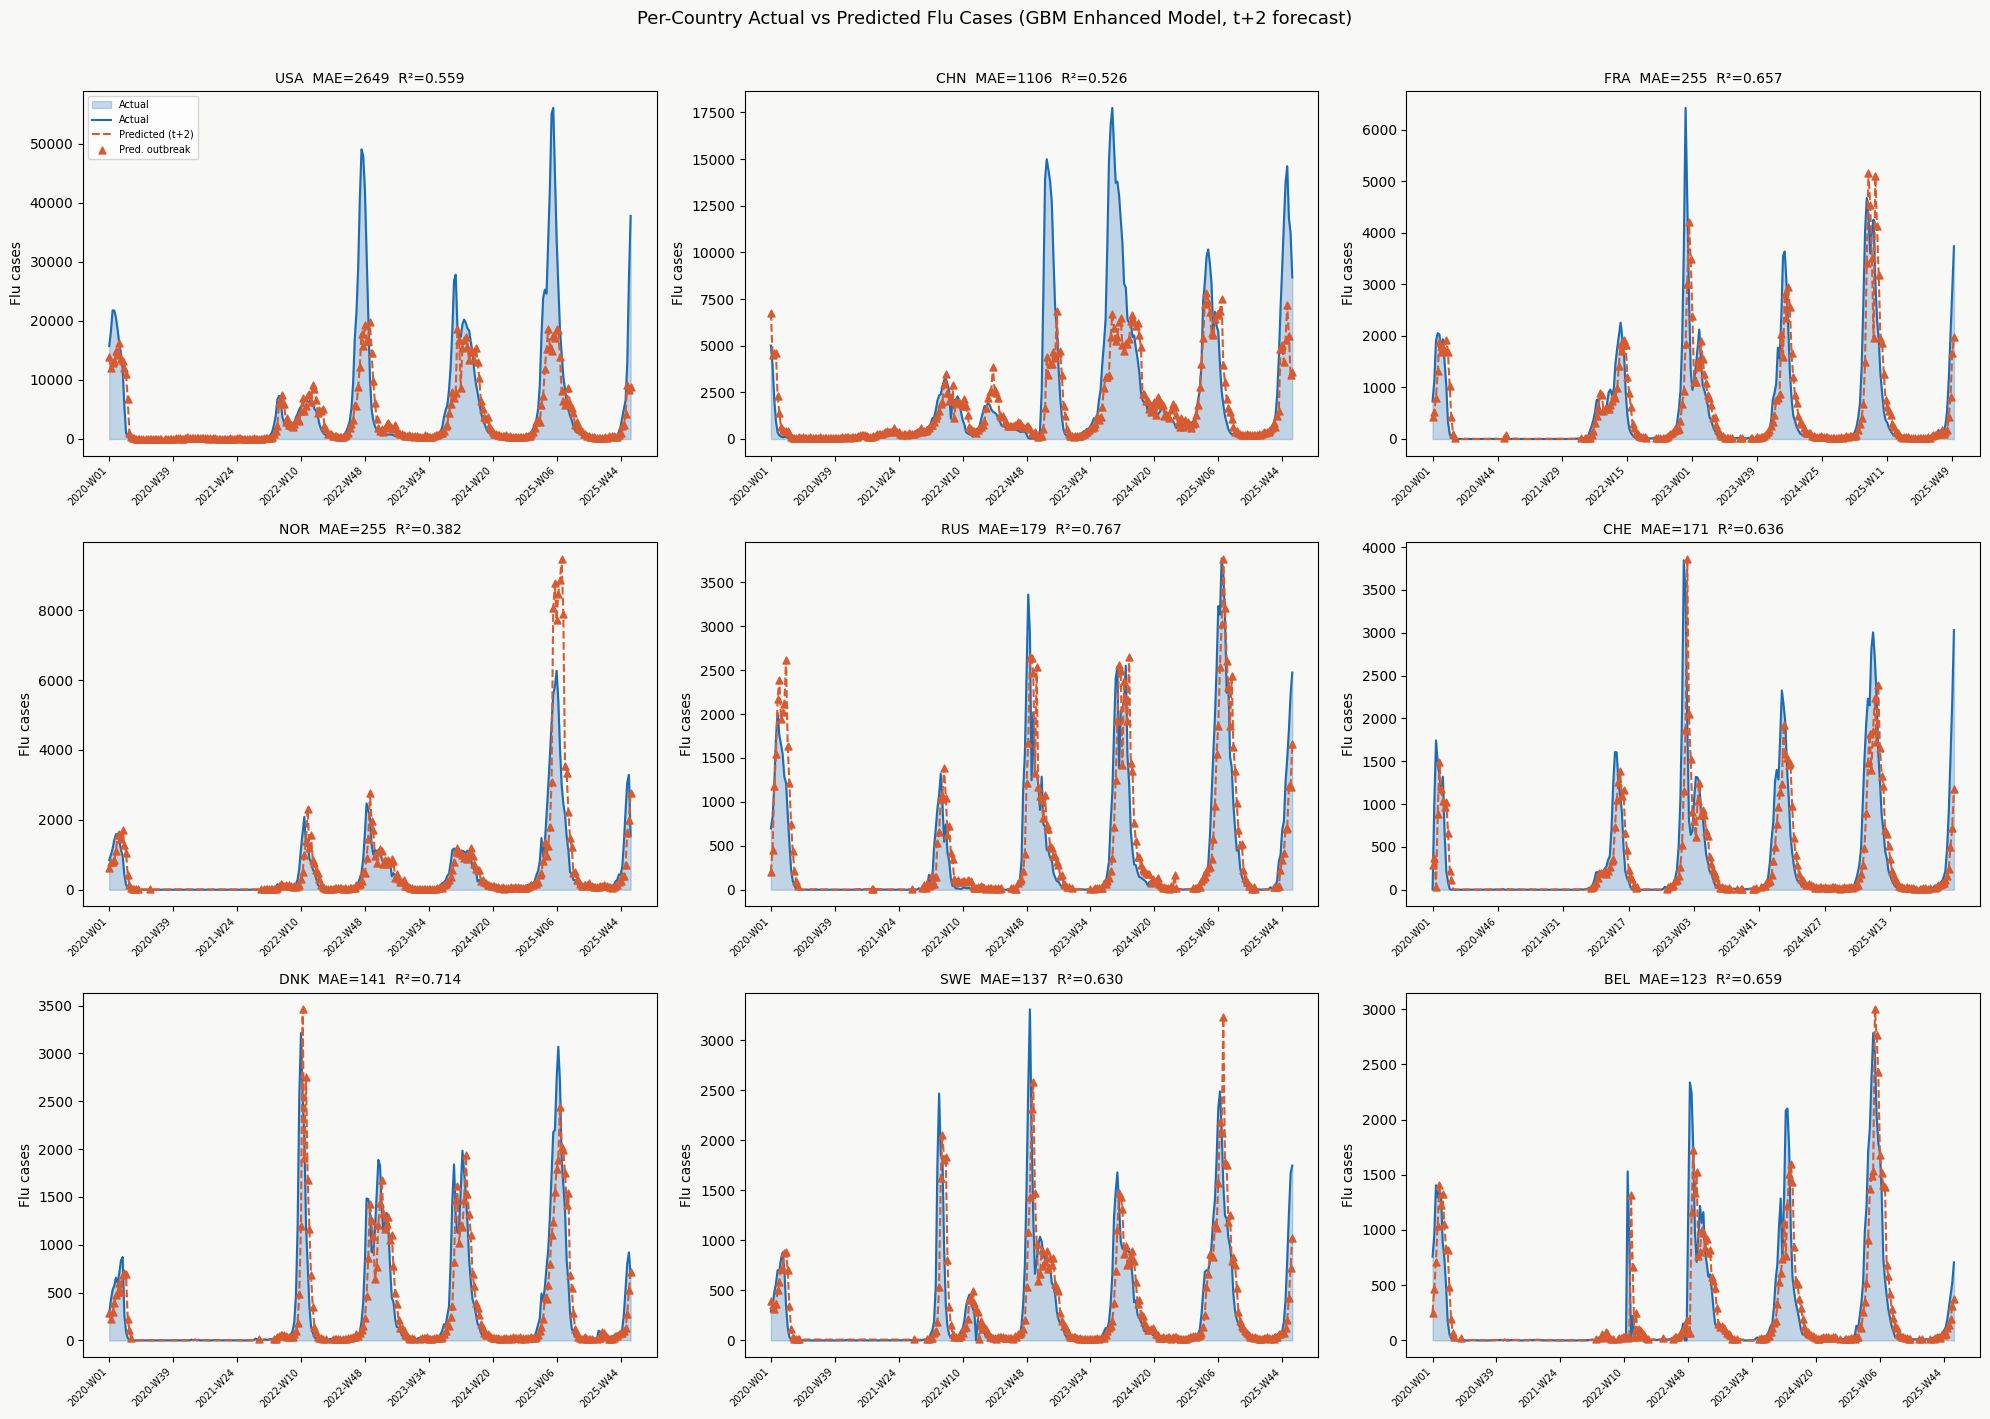

✓ Saved per_country_predictions.png  (9 countries)


In [9]:
# Use the best GBM enhanced model for per-country plots
best_gbm_key = results_df.loc[(results_df['algorithm']=='gbm')&(results_df['features']=='enhanced'), 'model'].values
best_gbm_key = best_gbm_key[0] if len(best_gbm_key) > 0 else best_key
best_gbm = trained_models[best_gbm_key]

# Attach predictions back to test dataframe
test_with_pred = best_gbm['test_df'].copy()
test_with_pred = test_with_pred.iloc[:len(best_gbm['pred'])].copy()
test_with_pred['pred_flu_t2']  = best_gbm['pred']
test_with_pred['actual_flu_t2'] = best_gbm['actual']
test_with_pred['residual']     = test_with_pred['actual_flu_t2'] - test_with_pred['pred_flu_t2']

# Select countries with most data points AND high flu burden
country_stats = test_with_pred.groupby('country_iso3').agg(
    n_weeks=('actual_flu_t2','count'),
    total_flu=('actual_flu_t2','sum'),
    mae_country=('residual', lambda x: x.abs().mean())
).query('n_weeks >= 10').nlargest(9, 'total_flu').index.tolist()

if not country_stats:
    # fallback: just take whichever countries have most records
    country_stats = test_with_pred.groupby('country_iso3').size().nlargest(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharey=False)
axes = axes.ravel()

for ax, country in zip(axes, country_stats):
    cdf = test_with_pred[test_with_pred['country_iso3']==country].sort_values(['year','week'])
    x   = np.arange(len(cdf))
    xlabels = cdf['year'].astype(str) + '-W' + cdf['week'].astype(str).str.zfill(2)

    ax.fill_between(x, 0, cdf['actual_flu_t2'], alpha=0.25, color='#1A6CB5', label='Actual')
    ax.plot(x, cdf['actual_flu_t2'], color='#1A6CB5', linewidth=1.5, label='Actual')
    ax.plot(x, cdf['pred_flu_t2'],   color='#D85A30', linewidth=1.5,
            linestyle='--', label='Predicted (t+2)')

    # Mark predicted outbreak weeks
    thresh = best_gbm['thresh']
    outbreak_mask = cdf['pred_flu_t2'] > thresh
    ax.scatter(x[outbreak_mask], cdf['pred_flu_t2'][outbreak_mask],
               color='#D85A30', zorder=5, s=25, marker='^', label='Pred. outbreak')

    mae_c = cdf['residual'].abs().mean()
    r2_c  = r2_score(cdf['actual_flu_t2'], cdf['pred_flu_t2']) if len(cdf) > 1 else float('nan')

    tick_step = max(1, len(x)//8)
    ax.set_xticks(x[::tick_step])
    ax.set_xticklabels(xlabels.iloc[::tick_step], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'{country}  MAE={mae_c:.0f}  R²={r2_c:.3f}', fontsize=10)
    ax.set_ylabel('Flu cases')
    ax.set_facecolor('#f8f8f6')
    if country == country_stats[0]:
        ax.legend(fontsize=7, loc='upper left')

fig.suptitle('Per-Country Actual vs Predicted Flu Cases (GBM Enhanced Model, t+2 forecast)',
             fontsize=13, y=1.01)
fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'per_country_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved per_country_predictions.png  ({len(country_stats)} countries)')

## 4.6 Lag Effect Analysis

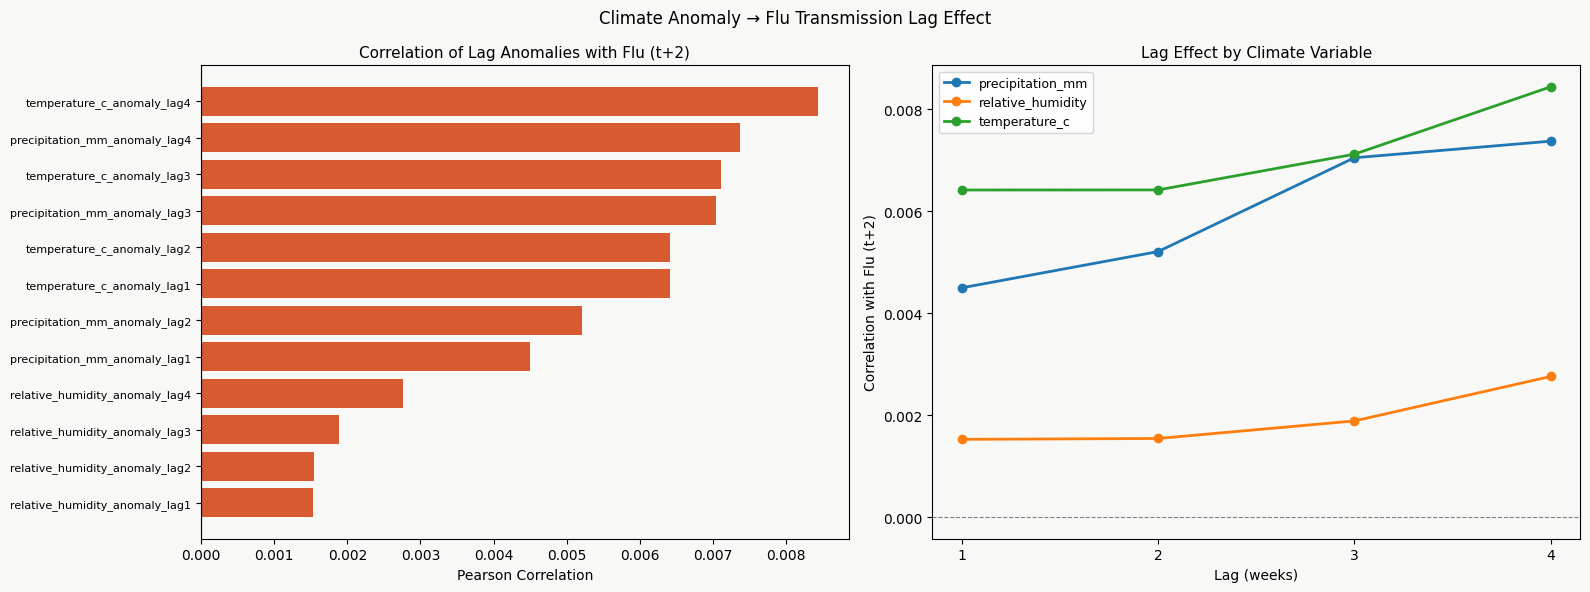

✓ Saved lag_effect_analysis.png

Strongest lag per climate variable:
  precipitation_mm      lag=4   r=0.0074
  relative_humidity     lag=4   r=0.0028
  temperature_c         lag=4   r=0.0084


In [10]:
lag_anomaly_cols = [c for c in df_master.columns if '_anomaly_lag' in c]

if lag_anomaly_cols:
    corr_data = df_master[lag_anomaly_cols + [TARGET]].dropna()
    lag_corrs = corr_data.corr()[TARGET].drop(TARGET).dropna()

    # Parse lag number and variable for grouped plot
    parsed = []
    for col, val in lag_corrs.items():
        parts = col.split('_lag')
        if len(parts) == 2:
            parsed.append({
                'col': col, 
                'variable': str(parts[0].replace('_anomaly','')), 
                'lag': int(parts[1]), 
                'corr': float(val)
            })
    parsed_df = pd.DataFrame(parsed)

    if not parsed_df.empty:
        # Use a consistent background color
        bg_color = '#f8f8f6'
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=bg_color)

        # Left: all lag correlations sorted
        sorted_corrs = lag_corrs.sort_values()
        colors = ['#D85A30' if c > 0 else '#1A6CB5' for c in sorted_corrs.values]
        axes[0].barh(sorted_corrs.index, sorted_corrs.values, color=colors)
        axes[0].axvline(0, color='black', linewidth=0.8)
        axes[0].set_title('Correlation of Lag Anomalies with Flu (t+2)', fontsize=11)
        axes[0].set_xlabel('Pearson Correlation')
        axes[0].set_facecolor(bg_color)
        axes[0].tick_params(axis='y', labelsize=8)

        # Right: lag effect by variable and lag number
        for var, grp in parsed_df.groupby('variable'):
            grp_s = grp.sort_values('lag')
            axes[1].plot(grp_s['lag'], grp_s['corr'], marker='o', linewidth=2, label=str(var))
        
        axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
        axes[1].set_xlabel('Lag (weeks)')
        axes[1].set_ylabel('Correlation with Flu (t+2)')
        axes[1].set_title('Lag Effect by Climate Variable', fontsize=11)
        axes[1].legend(fontsize=9)
        axes[1].set_facecolor(bg_color)
        axes[1].set_xticks(sorted(parsed_df['lag'].unique()))

        plt.suptitle('Climate Anomaly → Flu Transmission Lag Effect', fontsize=12)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR + 'lag_effect_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'✓ Saved lag_effect_analysis.png')

        # --- SAFER PRINTING SECTION ---
        print('\nStrongest lag per climate variable:')
        for var, grp in parsed_df.groupby('variable'):
            # Find index of max absolute correlation
            idx = grp['corr'].abs().idxmax()
            # Extract row and force values to standard Python types
            best_row = grp.loc[idx]
            
            # If multiple rows have same correlation, loc returns a DataFrame
            if isinstance(best_row, pd.DataFrame):
                best_row = best_row.iloc[0]

            v_name = str(var)
            v_lag  = int(best_row['lag'])
            v_corr = float(best_row['corr'])
            
            # Formatting as a simple string first to avoid any method.__format__ issues
            output_line = "  {:20s}  lag={:<2d}  r={:.4f}".format(v_name, v_lag, v_corr)
            print(output_line)
else:
    print('No lag anomaly columns — check Part 2 output')

## 4.6b Cross-Correlation Heatmap — Tại sao lag = 2?

Computing cross-correlation at multiple lag values...


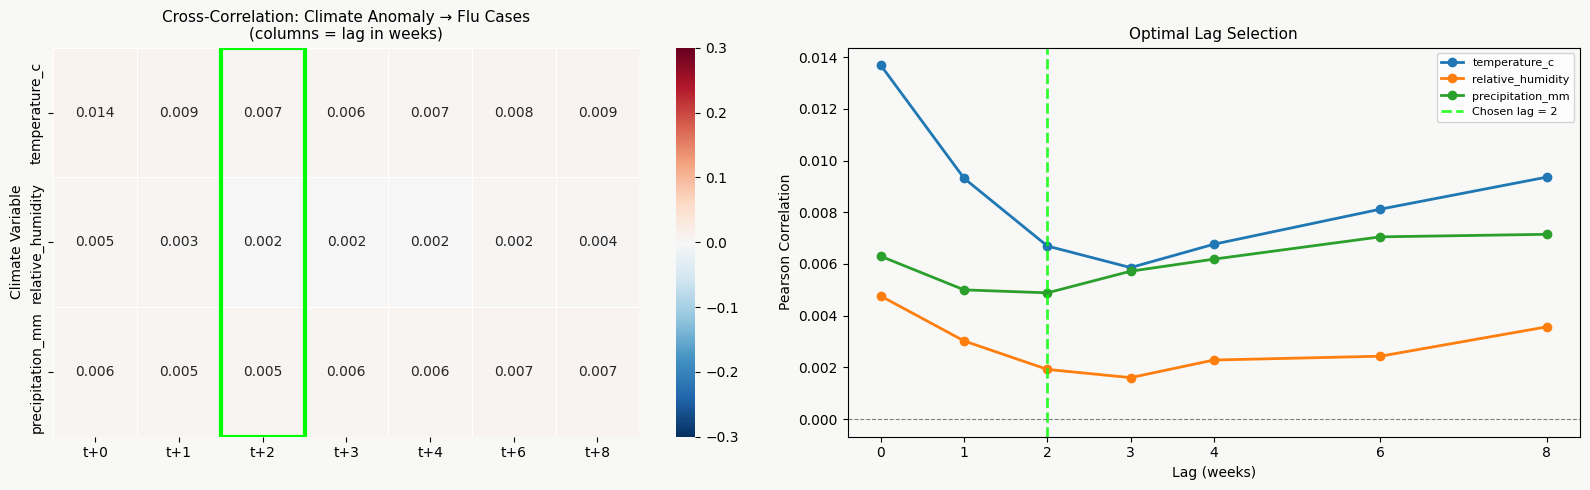


Optimal lag per variable (max |correlation|):
  temperature_c              best_lag = t+0  r = 0.0137
  relative_humidity          best_lag = t+0  r = 0.0048
  precipitation_mm           best_lag = t+8  r = 0.0071

  → Overall best lag: t+0 (mean |r| = 0.0082)
✓ Saved cross_correlation_heatmap.png


In [11]:
# ══════════════════════════════════════════════════════════════════
# Cross-Correlation: Climate Anomaly → Flu ở các lag khác nhau
# Chứng minh tại sao chọn lag = 2 tuần
# ══════════════════════════════════════════════════════════════════
print('Computing cross-correlation at multiple lag values...')

climate_anomaly_cols = [c for c in df_master.columns if '_anomaly' in c and '_lag' not in c]
flu_col = 'flu_cases_total'

if climate_anomaly_cols and flu_col in df_master.columns:
    lags_to_test = [0, 1, 2, 3, 4, 6, 8]

    # Tính correlation cho mỗi (climate_var, lag)
    corr_matrix = []
    for var in climate_anomaly_cols:
        row = {'variable': var.replace('_anomaly', '')}
        for lag in lags_to_test:
            shifted = df_master.groupby('country_iso3').apply(
                lambda g: g[[var, flu_col]].assign(
                    flu_shifted=g[flu_col].shift(-lag)
                ), include_groups=False
            ).reset_index(drop=True)
            valid = shifted.dropna(subset=[var, 'flu_shifted'])
            r = valid[var].corr(valid['flu_shifted']) if len(valid) > 30 else np.nan
            row[f't+{lag}'] = r
        corr_matrix.append(row)

    corr_df = pd.DataFrame(corr_matrix).set_index('variable')

    # ── Heatmap + Line plot ───────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(corr_df.astype(float), annot=True, fmt='.3f',
                cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
                linewidths=0.5, ax=axes[0])
    axes[0].set_title('Cross-Correlation: Climate Anomaly → Flu Cases\n(columns = lag in weeks)', fontsize=11)
    axes[0].set_ylabel('Climate Variable')

    # Highlight lag=2 column
    lag2_idx = lags_to_test.index(2)
    axes[0].add_patch(plt.Rectangle((lag2_idx, 0), 1, len(corr_df),
                                     fill=False, edgecolor='lime', linewidth=3))

    for var in corr_df.index:
        vals = corr_df.loc[var].values.astype(float)
        axes[1].plot(lags_to_test, vals, marker='o', linewidth=2, label=var)

    axes[1].axvline(2, color='lime', linewidth=2, linestyle='--', label='Chosen lag = 2', alpha=0.8)
    axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[1].set_xlabel('Lag (weeks)')
    axes[1].set_ylabel('Pearson Correlation')
    axes[1].set_title('Optimal Lag Selection', fontsize=11)
    axes[1].legend(fontsize=8)
    axes[1].set_xticks(lags_to_test)

    for ax in axes: ax.set_facecolor('#f8f8f6')
    fig.patch.set_facecolor('#f8f8f6')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR + 'cross_correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Optimal lag per variable
    print('\nOptimal lag per variable (max |correlation|):')
    for var in corr_df.index:
        vals = corr_df.loc[var].values.astype(float)
        best_idx = np.nanargmax(np.abs(vals))
        print(f'  {var:25s}  best_lag = t+{lags_to_test[best_idx]}  r = {vals[best_idx]:.4f}')

    mean_abs = corr_df.abs().mean()
    best_overall = mean_abs.idxmax()
    print(f'\n  → Overall best lag: {best_overall} (mean |r| = {mean_abs[best_overall]:.4f})')
    print(f'✓ Saved cross_correlation_heatmap.png')
else:
    print('No anomaly columns found — skipping cross-correlation')


## 4.7 Feature Importance (GBM Enhanced Model)

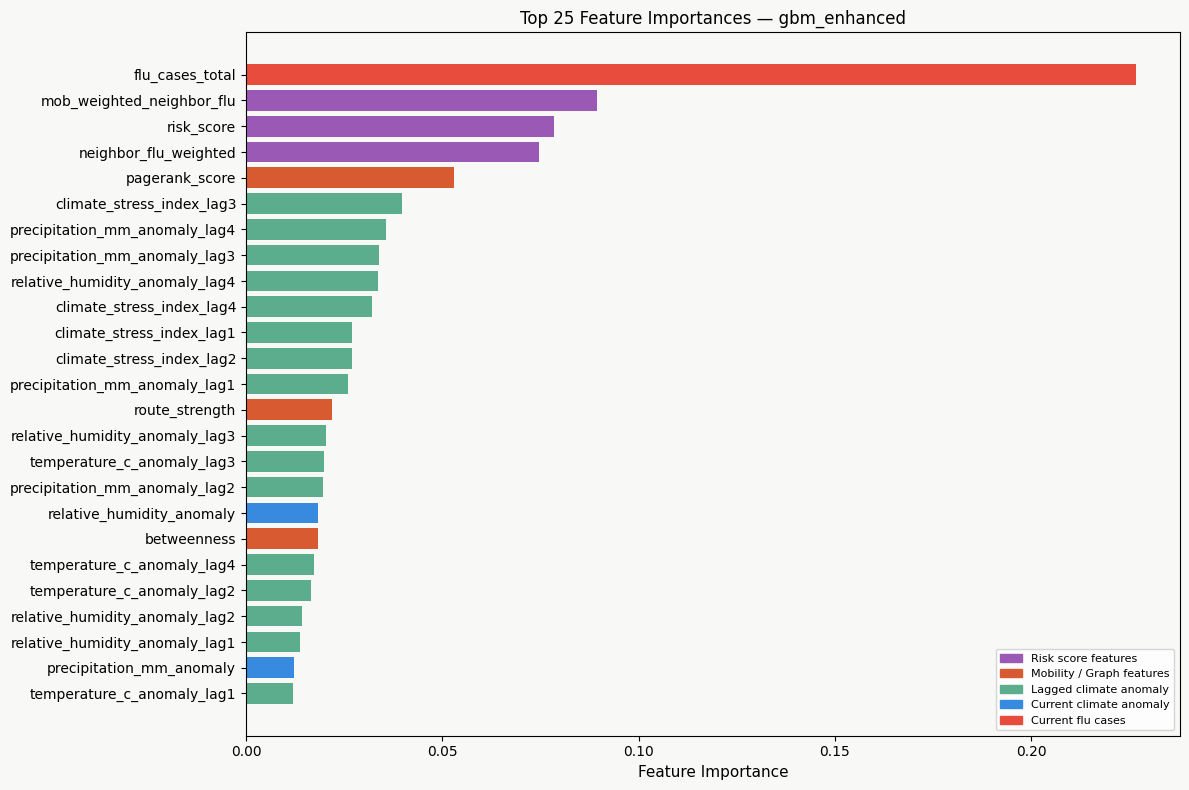

✓ Saved feature_importance.png

Feature importance by category:
  Risk score          : 0.2425 (24.7%)
  Mobility/Graph      : 0.1825 (18.6%)
  Lag climate         : 0.3883 (39.6%)
  Current climate     : 0.0306 (3.1%)
  Current flu         : 0.2265 (23.1%)


In [12]:
gbm_model = trained_models[best_gbm_key]['model']

if hasattr(gbm_model, 'feature_importances_'):
    feat_names = FEAT_ENH[:len(gbm_model.feature_importances_)]
    fi = pd.DataFrame({'feature': feat_names, 'importance': gbm_model.feature_importances_})
    fi = fi.sort_values('importance', ascending=False).head(25)

    # Color by feature type
    def feat_color(name):
        if 'risk' in name or 'neighbor_flu' in name:
            return '#9B59B6'  # risk features (purple)
        elif 'mob' in name or 'pagerank' in name or 'betweenness' in name or 'degree' in name or 'route' in name or 'tspr' in name:
            return '#D85A30'  # mobility/graph features (orange)
        elif 'lag' in name:
            return '#5CAD8E'  # lag climate features (green)
        elif 'anomaly' in name:
            return '#378ADD'  # current anomaly (blue)
        elif 'flu_cases' in name:
            return '#E74C3C'  # current flu (red)
        else:
            return '#888'

    fi_colors = [feat_color(n) for n in fi['feature']]

    fig, ax = plt.subplots(figsize=(12, 8))
    bars = ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=fi_colors[::-1])
    ax.set_xlabel('Feature Importance', fontsize=11)
    ax.set_title(f'Top {min(25, len(fi))} Feature Importances — {best_gbm_key}', fontsize=12)
    ax.set_facecolor('#f8f8f6')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#9B59B6', label='Risk score features'),
        Patch(color='#D85A30', label='Mobility / Graph features'),
        Patch(color='#5CAD8E', label='Lagged climate anomaly'),
        Patch(color='#378ADD', label='Current climate anomaly'),
        Patch(color='#E74C3C', label='Current flu cases'),
    ], fontsize=8, loc='lower right')

    fig.patch.set_facecolor('#f8f8f6')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved feature_importance.png')

    # Importance breakdown by category
    categories = {
        'Risk score':      lambda x: 'risk' in x or 'neighbor_flu' in x,
        'Mobility/Graph':  lambda x: any(k in x for k in ['mob','pagerank','tspr','between','degree','route']),
        'Lag climate':     lambda x: 'lag' in x,
        'Current climate': lambda x: 'anomaly' in x and 'lag' not in x,
        'Current flu':     lambda x: 'flu_cases' in x,
    }
    print(f'\nFeature importance by category:')
    for cat, fn in categories.items():
        imp = fi[fi['feature'].apply(fn)]['importance'].sum()
        if imp > 0:
            print(f'  {cat:20s}: {imp:.4f} ({imp/fi["importance"].sum()*100:.1f}%)')


## 4.8 Country Risk Ranking

Top 20 High-Risk Countries — Next 2 Weeks:
country_iso3  predicted_flu_next2w  composite_risk  risk_rank
         USA          36147.847807        1.000000          1
         CHN           8261.065631        0.299499          2
         ESP           1600.978551        0.270494          3
         DEU             26.849823        0.253614          4
         FRA           1982.822476        0.230183          5
         ITA           1190.420472        0.191797          6
         RUS           1683.897975        0.151782          7
         ARE            125.566435        0.125507          8
         JPN            420.437546        0.105127          9
         AUS            238.190928        0.092515         10
         NOR           2322.681994        0.084802         11
         CHE           1664.403551        0.083495         12
         NLD            289.593348        0.080887         13
         KOR            207.628889        0.076607         14
         IND              5

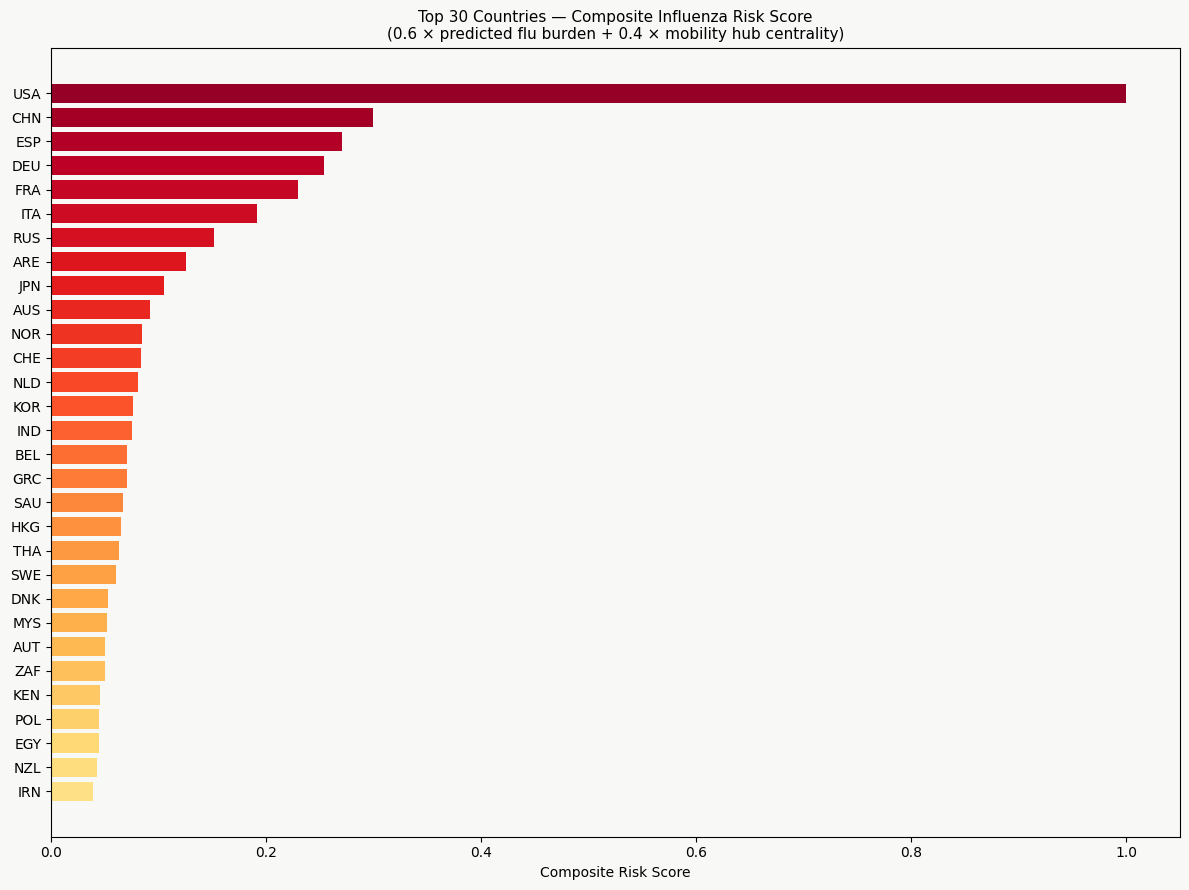

✓ Saved risk_ranking.png


In [13]:
latest = df_master.sort_values(['year','week']).groupby('country_iso3').last().reset_index()
avail  = [c for c in FEAT_ENH if c in latest.columns]

# Refit on all data
full_sub = df_master[avail+[TARGET]].dropna()
sc_full  = StandardScaler().fit(full_sub[avail].values)
gbm_full = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                      learning_rate=0.05, random_state=42)
gbm_full.fit(sc_full.transform(full_sub[avail].values), full_sub[TARGET].values)

X_lat  = sc_full.transform(latest[avail].fillna(0).values)
pred_r = np.maximum(gbm_full.predict(X_lat), 0)

risk_df = latest[['country_iso3']].copy()
risk_df['predicted_flu_next2w'] = pred_r
if 'pagerank_score' in latest.columns:
    pr_n   = latest['pagerank_score'].fillna(0) / (latest['pagerank_score'].max()+1e-9)
    flu_n  = pred_r / (pred_r.max()+1e-9)
    risk_df['composite_risk'] = 0.6*flu_n + 0.4*pr_n.values

score_col = 'composite_risk' if 'composite_risk' in risk_df.columns else 'predicted_flu_next2w'
risk_df = risk_df.sort_values(score_col, ascending=False).reset_index(drop=True)
risk_df['risk_rank'] = risk_df.index + 1

print('Top 20 High-Risk Countries — Next 2 Weeks:')
print(risk_df.head(20).to_string(index=False))

# Risk plot
top30 = risk_df.head(30)
fig, ax = plt.subplots(figsize=(12, 9))
palette = plt.cm.YlOrRd(np.linspace(0.2, 0.95, len(top30)))
ax.barh(top30['country_iso3'][::-1], top30[score_col][::-1], color=palette)
ax.set_title('Top 30 Countries — Composite Influenza Risk Score\n(0.6 × predicted flu burden + 0.4 × mobility hub centrality)',
             fontsize=11)
ax.set_xlabel('Composite Risk Score')
ax.set_facecolor('#f8f8f6'); fig.patch.set_facecolor('#f8f8f6')
plt.tight_layout()
plt.savefig(OUTPUT_DIR+'risk_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved risk_ranking.png')

## 4.9 Baseline vs Enhanced — Improvement Analysis

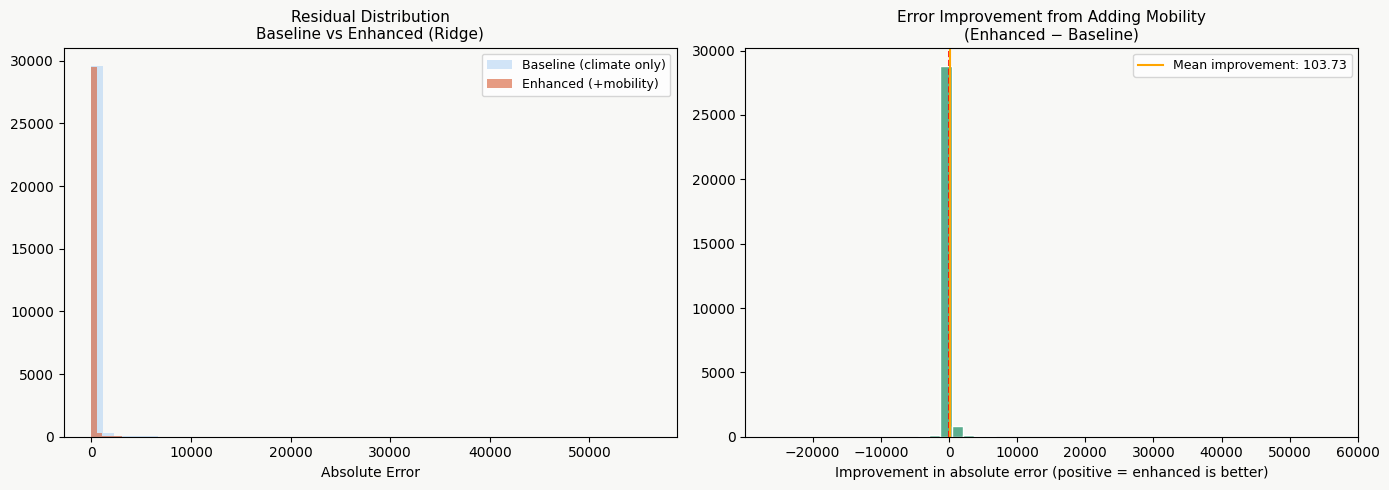

% of test records where enhanced model is better: 91.2%
Mean error reduction from adding mobility:        103.73 cases
✓ Saved mobility_improvement.png


In [14]:
# Residual comparison: does mobility help on high-traffic countries?
if 'ridge_baseline' in trained_models and 'ridge_enhanced' in trained_models:
    base_m = trained_models['ridge_baseline']
    enh_m  = trained_models['ridge_enhanced']

    # Align test sets (take intersection)
    te_b_aligned = te_b.copy().reset_index(drop=True)
    te_e_aligned = te_e.copy().reset_index(drop=True)
    common_len = min(len(base_m['pred']), len(enh_m['pred']))

    residuals_base = np.abs(base_m['actual'][:common_len] - base_m['pred'][:common_len])
    residuals_enh  = np.abs(enh_m['actual'][:common_len]  - enh_m['pred'][:common_len])
    improvement    = residuals_base - residuals_enh

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: residual distribution
    axes[0].hist(residuals_base, bins=50, alpha=0.6, color='#B5D4F4', label='Baseline (climate only)')
    axes[0].hist(residuals_enh,  bins=50, alpha=0.6, color='#D85A30', label='Enhanced (+mobility)')
    axes[0].set_xlabel('Absolute Error')
    axes[0].set_title('Residual Distribution\nBaseline vs Enhanced (Ridge)', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].set_facecolor('#f8f8f6')

    # Right: improvement histogram
    axes[1].hist(improvement, bins=50, color='#5CAD8E', edgecolor='white')
    axes[1].axvline(0, color='red', linewidth=1.2, linestyle='--')
    axes[1].axvline(improvement.mean(), color='orange', linewidth=1.5, linestyle='-',
                    label=f'Mean improvement: {improvement.mean():.2f}')
    axes[1].set_xlabel('Improvement in absolute error (positive = enhanced is better)')
    axes[1].set_title('Error Improvement from Adding Mobility\n(Enhanced − Baseline)', fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].set_facecolor('#f8f8f6')

    for ax in axes: ax.figure.patch.set_facecolor('#f8f8f6')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR+'mobility_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()

    pct_improved = (improvement > 0).mean()
    print(f'% of test records where enhanced model is better: {pct_improved:.1%}')
    print(f'Mean error reduction from adding mobility:        {improvement.mean():.2f} cases')
    print(f'✓ Saved mobility_improvement.png')

## 4.10 Final Summary

In [15]:
# ══════════════════════════════════════════════════════════════════
# 4.10 Final Export — deploy the best model by VALIDATION RMSE
# ══════════════════════════════════════════════════════════════════
best_overall_key = results_df.loc[results_df['Val_RMSE'].astype(float).idxmin(), 'model']
is_gnn = (best_overall_key == 'gnn_a3tgcn')
print(f'Deploying best-by-val-RMSE model: {best_overall_key}'
      f'  (Val_RMSE={results_df.loc[results_df["model"]==best_overall_key,"Val_RMSE"].values[0]})')

all_data = df_master[FEAT_ENH + [TARGET, 'country_iso3', 'year', 'week']].copy()
if 'flu_cases_total' in df_master.columns and 'flu_cases_total' not in all_data.columns:
    all_data['flu_cases_total'] = df_master['flu_cases_total']
all_data = all_data.dropna(subset=[TARGET]).copy()
all_data['actual_cases']    = all_data[TARGET]
all_data['split']           = np.where(all_data['year'] >= 2020, 'test', 'train')
all_data['predicted_cases'] = np.nan
test_mask = all_data['year'] >= 2020

if is_gnn:
    # GNN predicts per (country, week) for masked test cells — map them in
    pred_map = gnn_pred_df.set_index(['country_iso3', 'year', 'week'])['pred']
    keys = list(zip(all_data['country_iso3'], all_data['year'], all_data['week']))
    all_data['predicted_cases'] = pd.Series(keys, index=all_data.index).map(pred_map)
    FEAT_PREDICT = FEAT_GNN
else:
    bm = trained_models[best_overall_key]['model']
    FEAT_PREDICT, sc_use = (FEAT_ENH, sc_e) if 'enhanced' in best_overall_key else (FEAT_BASE, sc_b)
    n_feats = getattr(bm, 'n_features_in_', len(FEAT_PREDICT))
    FEAT_PREDICT = FEAT_PREDICT[:n_feats]
    pred_idx = all_data.index[test_mask & all_data[FEAT_PREDICT].notna().all(axis=1)]
    if len(pred_idx) > 0:
        Xt = sc_use.transform(all_data.loc[pred_idx, FEAT_PREDICT].values)
        all_data.loc[pred_idx, 'predicted_cases'] = np.maximum(bm.predict(Xt), 0)

print(f'Train (<2020): {(~test_mask).sum():,} rows — actual only')
print(f'Test  (>=2020): {test_mask.sum():,} rows | predictions: {all_data["predicted_cases"].notna().sum():,}')

# Enrich for the dashboard (same schema as before)
anomaly_present = [c for c in all_data.columns if '_anomaly' in c and '_lag' not in c]
if anomaly_present:
    all_data['climate_anomaly_index'] = all_data[anomaly_present].mean(axis=1)
for col in ['pagerank_score', 'community_id', 'community', 'tspr_score', 'betweenness', 'degree_centrality']:
    if col not in all_data.columns and col in graph.columns:
        all_data = all_data.merge(graph[['country_iso3', col]].drop_duplicates(), on='country_iso3', how='left')
if 'community' in all_data.columns and 'community_id' not in all_data.columns:
    all_data = all_data.rename(columns={'community': 'community_id'})
if 'risk_score' not in all_data.columns and HAS_RISK and len(risk_ts) > 0:
    all_data = all_data.merge(risk_ts[['country_iso3','year','week','risk_score']].drop_duplicates(),
                              on=['country_iso3','year','week'], how='left')
if 'risk_score' in all_data.columns:
    all_data['risk_level'] = pd.cut(all_data['risk_score'].fillna(0),
                                    bins=[-1, 33, 66, 100], labels=['Low', 'Medium', 'High'])
else:
    pc = all_data['predicted_cases']
    q33, q66 = pc.dropna().quantile(0.33), pc.dropna().quantile(0.66)
    all_data['risk_level'] = pd.cut(pc, bins=[-1, max(q33,0.01), max(q66,0.02), pc.max()+1],
                                    labels=['Low', 'Medium', 'High'])
all_data['week_id'] = all_data['year'].astype(int).astype(str) + '-W' + all_data['week'].astype(int).astype(str).str.zfill(2)

final_cols = ['country_iso3', 'week_id', 'year', 'week', 'split',
              'actual_cases', 'predicted_cases', 'flu_cases_total',
              'climate_anomaly_index', 'pagerank_score', 'community_id',
              'risk_score', 'risk_level', 'mob_weighted_neighbor_flu',
              'tspr_score', 'betweenness', 'degree_centrality']
final_cols = [c for c in final_cols if c in all_data.columns]
final_results = all_data[final_cols].sort_values(['country_iso3','year','week']).reset_index(drop=True)

final_results.to_parquet(OUTPUT_DIR + 'final_results.parquet', index=False)
results_df.to_parquet(OUTPUT_DIR + 'model_results.parquet', index=False)
risk_df.to_parquet(OUTPUT_DIR + 'country_risk_scores.parquet', index=False)

# Deployable bundle — torch state_dict if GNN won, else the sklearn estimator
if is_gnn:
    model_bundle = {
        'best_key': best_overall_key, 'algorithm': 'gnn',
        'state_dict': {k: v.cpu() for k, v in gnn.state_dict().items()},
        'config': {'F': F, 'hidden': 32, 'L': L, 'features': FEAT_GNN + ['observed_mask'],
                   'node_order': nodes, 'target_log': True, 'edge_pruning': 'none'},
        'edge_index': edge_index.cpu().numpy(), 'edge_weight': edge_weight.cpu().numpy(),
        'scaler': sc_gnn, 'results': results_df.to_dict('records'),
    }
else:
    model_bundle = {
        'best_key': best_overall_key, 'algorithm': trained_models[best_overall_key]['model'].__class__.__name__,
        'model': trained_models[best_overall_key]['model'], 'scaler': sc_use,
        'features': FEAT_PREDICT, 'target': TARGET, 'results': results_df.to_dict('records'),
    }
joblib.dump(model_bundle, OUTPUT_DIR + 'flu_model.pkl')

print('=' * 65)
print('FINAL OUTPUT')
print('=' * 65)
print(f'final_results.parquet : {len(final_results):,} rows | {final_results["country_iso3"].nunique()} countries')
print(f'flu_model.pkl         : {best_overall_key} ({len(FEAT_PREDICT)} features)')
print('\nLeaderboard (sorted by validation RMSE):')
print(results_df[['model','Val_RMSE','MAE','RMSE','R2','F1']]
      .sort_values('Val_RMSE').to_string(index=False))
print(f'\n🏆 Deployed: {best_overall_key}')


Deploying best-by-val-RMSE model: ridge_enhanced  (Val_RMSE=301.639)
Train (<2020): 58,063 rows — actual only
Test  (>=2020): 31,917 rows | predictions: 30,043
FINAL OUTPUT
final_results.parquet : 89,980 rows | 119 countries
flu_model.pkl         : ridge_enhanced (28 features)

Leaderboard (sorted by validation RMSE):
         model  Val_RMSE     MAE     RMSE      R2    F1
ridge_enhanced   301.639  57.789  552.371  0.8022 0.751
  gbm_enhanced   324.121  65.713  734.865  0.6500 0.817
    gnn_a3tgcn   561.427 128.475 1034.810  0.2631 0.598
  gbm_baseline   804.697 157.939 1198.938  0.0136 0.432
ridge_baseline   808.494 164.928 1208.166 -0.0017 0.426

🏆 Deployed: ridge_enhanced
